In [15]:
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Leitura direta do arquivo Parquet (uma pasta acima de /classificacao)
df_original = pd.read_parquet('../Imdb_Movie_Dataset.parquet')
print("Dados carregados com sucesso para o pipeline do LightGBM!")

Dados carregados com sucesso para o pipeline do LightGBM!


In [16]:
df = df_original.copy()

LIMIAR_NOTA_MINIMA = 6.8
LIMIAR_VOTOS_MINIMOS = 20
LIMIAR_VOTOS_MAXIMOS = 3000

condicao_nota = df['vote_average'] >= LIMIAR_NOTA_MINIMA
condicao_votos_min = df['vote_count'] >= LIMIAR_VOTOS_MINIMOS
condicao_votos_max = df['vote_count'] <= LIMIAR_VOTOS_MAXIMOS

df['sucesso_nicho'] = (condicao_nota & condicao_votos_min & condicao_votos_max).astype(int)

print("Distribuição da variável-alvo:")
print(df['sucesso_nicho'].value_counts())

Distribuição da variável-alvo:
sucesso_nicho
0    937013
1     14542
Name: count, dtype: int64


In [17]:
# One-Hot Encoding para a variável 'genres'
df['genres_limpo'] = df['genres'].astype(str).str.replace(r'[\(\)\[\]\']', '', regex=True).str.replace(' ', '')
df_genres = df['genres_limpo'].str.get_dummies(sep=',').add_prefix('genero_')

# Agrupamento de idiomas minoritários e aplicação de One-Hot Encoding
top_idiomas = df['original_language'].value_counts().head(5).index
df['idioma_agrupado'] = df['original_language'].where(df['original_language'].isin(top_idiomas), 'outros')
df_idiomas = pd.get_dummies(df['idioma_agrupado'], prefix='idioma', dtype=int)

# Extração da feature temporal (ano)
df['release_year'] = pd.to_datetime(df['release_date'], format='mixed', errors='coerce').dt.year

# Agrupamento das variáveis independentes numéricas
pistas_numericas = df[['runtime', 'revenue', 'release_year']].fillna(0)

# Concatenação do dataframe final de features (X) e isolamento do vetor alvo (y)
X = pd.concat([pistas_numericas, df_genres, df_idiomas], axis=1)
y = df['sucesso_nicho']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)


In [19]:
# --- TESTE DE VAZAMENTO DE DADOS (TARGET LEAKAGE) ---
print("Tamanho antigo do X_train:", X_train.shape)

# Removendo os "valentões" para forçar o modelo a olhar para os gêneros e receita
X_train = X_train.drop(columns=['release_year', 'runtime'])
X_test = X_test.drop(columns=['release_year', 'runtime'])

print("Variáveis 'release_year' e 'runtime' foram removidas com sucesso!")
print("Tamanho novo do X_train:", X_train.shape)

Tamanho antigo do X_train: (761244, 28)
Variáveis 'release_year' e 'runtime' foram removidas com sucesso!
Tamanho novo do X_train: (761244, 26)


In [20]:
# Instanciação do classificador LightGBM
# O parâmetro class_weight='balanced' aplica penalidades inversamente proporcionais às frequências das classes
modelo_lgbm = LGBMClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Ajuste do modelo aos dados de treino
modelo_lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 11557, number of negative: 749687
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.134920 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 305
[LightGBM] [Info] Number of data points in the train set: 761244, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [21]:
# Geração de previsões baseadas no conjunto de teste
previsoes_lgbm = modelo_lgbm.predict(X_test)

# Cálculo e exibição das métricas de avaliação
print(f"Acurácia Geral: {accuracy_score(y_test, previsoes_lgbm):.4f}\n")

print("Relatório de Classificação:")
print(classification_report(y_test, previsoes_lgbm, digits=4))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, previsoes_lgbm))

Acurácia Geral: 0.7618

Relatório de Classificação:
              precision    recall  f1-score   support

           0     0.9949    0.7620    0.8630    187326
           1     0.0481    0.7544    0.0904      2985

    accuracy                         0.7618    190311
   macro avg     0.5215    0.7582    0.4767    190311
weighted avg     0.9800    0.7618    0.8509    190311


Matriz de Confusão:
[[142735  44591]
 [   733   2252]]


<Figure size 1000x600 with 0 Axes>

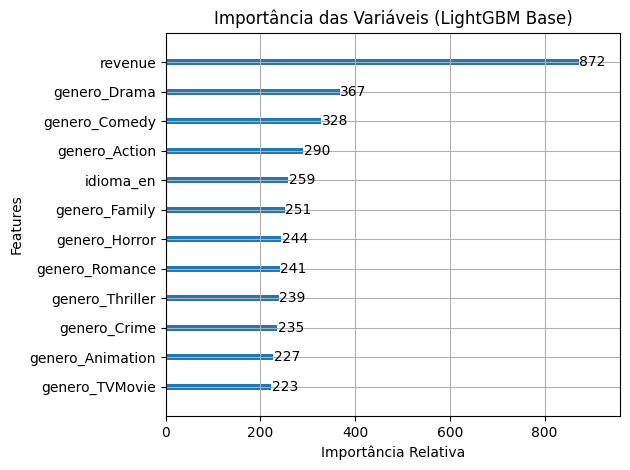

In [22]:
# Geração do gráfico de Feature Importance
import joblib
from lightgbm import plot_importance

plt.figure(figsize=(10, 6))
plot_importance(modelo_lgbm, max_num_features=12, title="Importância das Variáveis (LightGBM Base)", xlabel="Importância Relativa", ylabel="Features")
plt.tight_layout()
plt.show()

Iniciando a sintonia fina do LightGBM. O robô está a testar as combinações...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
[LightGBM] [Info] Number of positive: 7705, number of negative: 499791
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.163408 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 305
[LightGBM] [Info] Number of data points in the train set: 507496, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 7705, number of negative: 499791
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.062702 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[Light

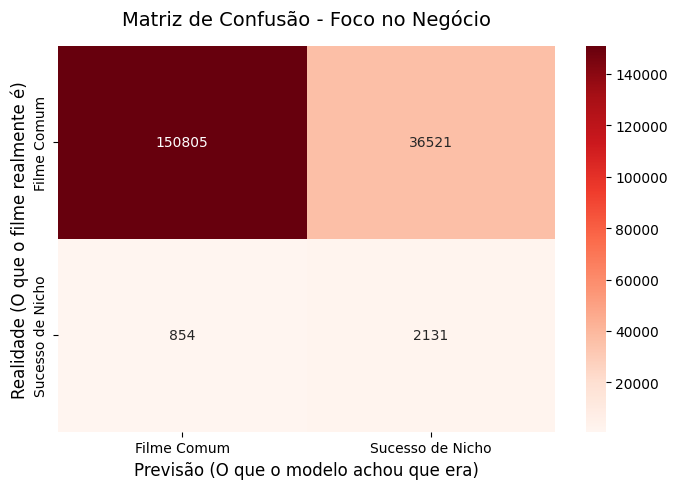

In [23]:
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMClassifier

print("Iniciando a sintonia fina do LightGBM. O robô está a testar as combinações...")

parametros_lgbm = {
    'num_leaves': [15, 31, 50],       
    'learning_rate': [0.05, 0.1],      
    'min_child_samples': [20, 50, 100]  
}

lgbm_base = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

grid_lgbm = GridSearchCV(
    estimator=lgbm_base,
    param_grid=parametros_lgbm,
    cv=3,                 
    scoring='f1',       
    verbose=1             
)

grid_lgbm.fit(X_train, y_train)

print("\n" + "="*50)
print("SINTONIA CONCLUÍDA!")
print("Os parâmetros campeões para reduzir falsos positivos são:")
print(grid_lgbm.best_params_)
print(f"O melhor F1-Score alcançado foi: {grid_lgbm.best_score_:.4f}")
print("="*50)

modelo_campeao = grid_lgbm.best_estimator_
previsoes_campeao = modelo_campeao.predict(X_test)

nomes_das_classes = ['Filme Comum', 'Sucesso de Nicho']

print("=== RESULTADOS DO MODELO ===")
print(classification_report(y_test, previsoes_campeao, target_names=nomes_das_classes))

plt.figure(figsize=(7,5))

sns.heatmap(
    confusion_matrix(y_test, previsoes_campeao), 
    annot=True, 
    fmt='d', 
    cmap='Reds', 
    xticklabels=nomes_das_classes, 
    yticklabels=nomes_das_classes
)

plt.title('Matriz de Confusão - Foco no Negócio', fontsize=14, pad=15)
plt.ylabel('Realidade (O que o filme realmente é)', fontsize=12)
plt.xlabel('Previsão (O que o modelo achou que era)', fontsize=12)

plt.tight_layout()
plt.show()

In [24]:
import pandas as pd

importancias = modelo_campeao.feature_importances_
features = modelo_campeao.feature_name_

df_pareto = pd.DataFrame({'Variavel': features, 'Importancia': importancias})
df_pareto = df_pareto.sort_values(by='Importancia', ascending=False)

df_pareto['Importancia_Acumulada_Perc'] = (df_pareto['Importancia'].cumsum() / df_pareto['Importancia'].sum()) * 100

print("=== ANÁLISE DE PARETO NAS VARIÁVEIS ===")
print("Mostrando quantas variáveis são necessárias para atingir 80% do aprendizado do modelo:\n")
print(df_pareto.head(10))

=== ANÁLISE DE PARETO NAS VARIÁVEIS ===
Mostrando quantas variáveis são necessárias para atingir 80% do aprendizado do modelo:

            Variavel  Importancia  Importancia_Acumulada_Perc
0            revenue          568                   11.591837
21         idioma_en          264                   16.979592
7       genero_Drama          261                   22.306122
1      genero_Action          256                   27.530612
4      genero_Comedy          208                   31.775510
3   genero_Animation          201                   35.877551
14    genero_Romance          200                   39.959184
8      genero_Family          198                   44.000000
11     genero_Horror          196                   48.000000
17   genero_Thriller          194                   51.959184


=== MÉTRICA DE PARETO (TOP 20%) ===
Nota de corte matemática encontrada: Probabilidade >= 0.5080

                  precision    recall  f1-score   support

     Filme Comum       0.99      0.81      0.89    187326
Sucesso de Nicho       0.06      0.71      0.10      2985

        accuracy                           0.81    190311
       macro avg       0.52      0.76      0.50    190311
    weighted avg       0.98      0.81      0.88    190311



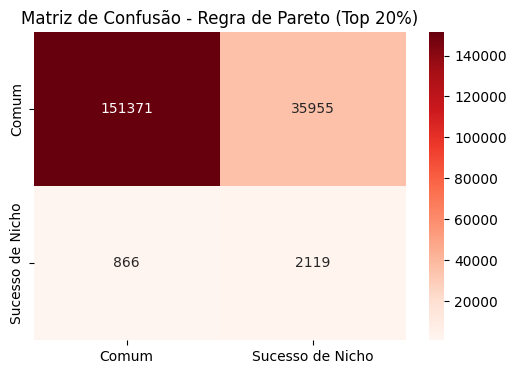

In [25]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Pegamos a probabilidade exata (0 a 100%) em vez do Sim/Não
probabilidades = modelo_campeao.predict_proba(X_test)[:, 1]

# 2. Aplicamos PARETO: Achamos a nota de corte que separa o "Top 20%" dos filmes
limiar_pareto = np.percentile(probabilidades, 80) 

# 3. Criamos uma nova regra: Só é "Sucesso de Nicho" se estiver no Top 20%
previsoes_pareto = (probabilidades >= limiar_pareto).astype(int)

print(f"=== MÉTRICA DE PARETO (TOP 20%) ===")
print(f"Nota de corte matemática encontrada: Probabilidade >= {limiar_pareto:.4f}\n")
print(classification_report(y_test, previsoes_pareto, target_names=['Filme Comum', 'Sucesso de Nicho']))

# Desenhando a Matriz de Confusão do Pareto
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, previsoes_pareto), annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Comum', 'Sucesso de Nicho'], yticklabels=['Comum', 'Sucesso de Nicho'])
plt.title('Matriz de Confusão - Regra de Pareto (Top 20%)')
plt.show()

In [26]:
import joblib

caminho_modelo = 'models/lgbm_sucesso_nicho_model.pkl'
joblib.dump(modelo_campeao, caminho_modelo)

print(f"Modelo CAMPEÃO salvo com sucesso na pasta models!")

Modelo CAMPEÃO salvo com sucesso na pasta models!
